In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

df = df[['Open','High','Low','Close','Volume']]

# tính return
df['return'] = df['Close'].pct_change()

# log return
df['log_return'] = np.log(df['Close']/df['Close'].shift(1))

df = df.dropna()

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume,return,log_return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2015-01-05,23.984547,24.064282,23.346673,23.532719,257142000,-0.028172,-0.028576
2015-01-06,23.596954,23.794075,23.173918,23.534939,263188400,0.000094,0.000094
2015-01-07,23.743131,23.964616,23.632389,23.864948,160423600,0.014022,0.013925
2015-01-08,24.192743,24.839477,24.075355,24.781891,237458000,0.038422,0.037702
2015-01-09,24.954654,25.083116,24.409803,24.808475,214798000,0.001073,0.001072


**LAB 1 – RSI dựa trên phân phối (Distribution-aware RSI)**
Yêu cầu:  
• Thay RSI cổ điển bằng:  
o RSI tính trên returns đã chuẩn hóa theo volatility  
• So sánh RSI chuẩn vs RSI volatility-adjusted trong giai đoạn khủng hoảng.

In [4]:
def compute_RSI(series, window=14):
    
    delta = series.diff()
    
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    
    rs = gain / loss
    
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

df['RSI_standard'] = compute_RSI(df['Close'],14)

In [5]:
# rolling volatility
df['volatility'] = df['return'].rolling(14).std()

# normalized return
df['vol_adj_return'] = df['return'] / df['volatility']

In [6]:

df['RSI_vol_adj'] = compute_RSI(df['vol_adj_return'],14)

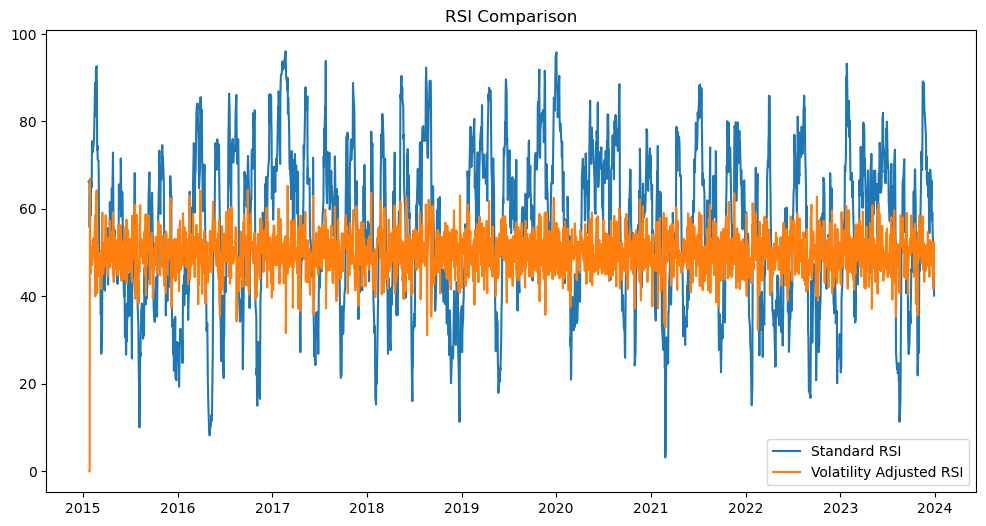

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['RSI_standard'],label="Standard RSI")
plt.plot(df['RSI_vol_adj'],label="Volatility Adjusted RSI")
plt.legend()
plt.title("RSI Comparison")
plt.show()

**LAB 2 – Hidden Markov Model cho Regime-Switching RSI**  
Yêu cầu:
✓ Tính:   
o log return  
o rolling volatility  
o RSI truyền thống   
✓ Huấn luyện Hidden Markov Model với:  
o X = [return, volatility, RSI]  
✓ Xác định regimes:  
o Bull trend  
o Bear trend  
o Sideway  
✓ Với mỗi regime:  
o RSI window khác nhau: 7, 14, 28  
o Overbought/Oversold khác nhau  
✓ So sánh:  
o RSI cố định vs Regime RSI  

[*********************100%***********************]  1 of 1 completed
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
Model is not converging.  Current: 6810.43600882364 is not greater than 6810.455245067528. Delta is -0.019236243888371973


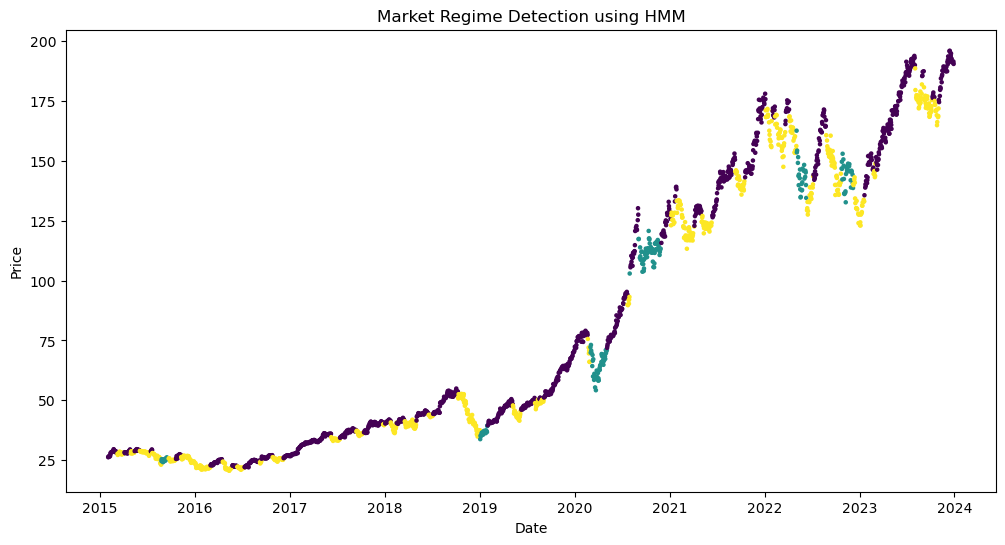

Price            Close        RSI volatility regime
Ticker            AAPL                             
Date                                               
2023-12-22  191.609482  54.672824   0.009071    0.0
2023-12-26  191.065125  53.090027   0.009103    0.0
2023-12-27  191.164108  53.354468   0.009086    0.0
2023-12-28  191.589661  54.540940   0.008973    0.0
2023-12-29  190.550461  51.121303   0.009078    0.0


In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ta.momentum import RSIIndicator
from hmmlearn.hmm import GaussianHMM

df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

df = df[['Open','High','Low','Close','Volume']]

close = df['Close'].squeeze()

df['return'] = close.pct_change()

df['log_return'] = np.log(close / close.shift(1))

df['RSI'] = RSIIndicator(close=close, window=14).rsi()

df['volatility'] = df['return'].rolling(20).std()

features = df[['log_return','volatility','RSI']].dropna()

model = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000)

model.fit(features)

hidden_states = model.predict(features)

df['regime'] = np.nan
df.loc[features.index, 'regime'] = hidden_states

plt.figure(figsize=(12,6))

plt.scatter(df.index, close, c=df['regime'], cmap='viridis', s=5)

plt.title("Market Regime Detection using HMM")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()
print(df[['Close','RSI','volatility','regime']].tail())

**LAB 3 – Hierarchical Multi-Timeframe MACD Trend Confirmation**  
Yêu cầu:  
✓ Tính MACD trên:  
o Daily  
o 1H  
o 5min  
✓ Logic:  
o Trade only if:  
MACD_D1 trend agrees with MACD_H1  
Entry when MACD_M5 crosses signal  
✓ Đánh giá:  
o False breakout reduction  
o Profit factor

[*********************100%***********************]  1 of 1 completed


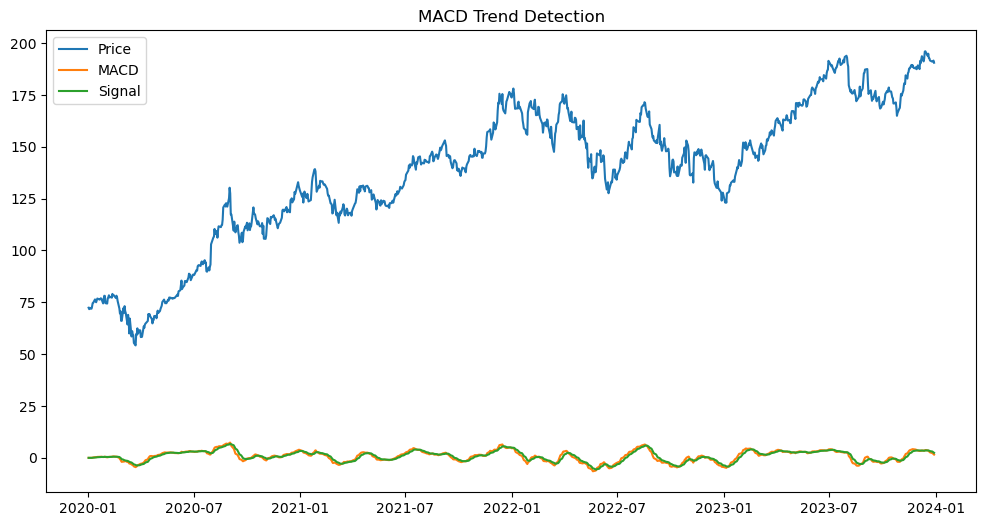

In [13]:
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

close = df['Close'].squeeze()

# MACD function
def MACD(price):
    ema12 = price.ewm(span=12).mean()
    ema26 = price.ewm(span=26).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9).mean()
    return macd, signal

df['macd'], df['signal'] = MACD(close)

df['trend'] = np.where(df['macd'] > df['signal'],1,-1)

plt.figure(figsize=(12,6))
plt.plot(close,label="Price")
plt.plot(df['macd'],label="MACD")
plt.plot(df['signal'],label="Signal")
plt.legend()
plt.title("MACD Trend Detection")
plt.show()

**LAB 4 – RSI + MACD như feature cho mô hình**  
Yêu cầu:  
• Không dùng RSI/MACD để ra quyết định trực tiếp.  
• Trích xuất feature:  
o RSI slope  
o RSI entropy  
o MACD histogram acceleration  
• Huấn luyện model (XGBoost/Bayes) dự đoán return 1–5 ngày.  


In [14]:
from ta.momentum import RSIIndicator
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

close = df['Close'].squeeze()

df['RSI'] = RSIIndicator(close,14).rsi()

ema12 = close.ewm(span=12).mean()
ema26 = close.ewm(span=26).mean()

df['MACD'] = ema12-ema26
df['MACD_signal'] = df['MACD'].ewm(span=9).mean()

df['MACD_hist'] = df['MACD']-df['MACD_signal']

df['RSI_slope'] = df['RSI'].diff()

df['MACD_acceleration'] = df['MACD_hist'].diff()

df['target'] = close.pct_change(3).shift(-3)

data = df[['RSI','RSI_slope','MACD_hist','MACD_acceleration','target']].dropna()

X = data.drop('target',axis=1)
y = data['target']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = XGBRegressor()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("MSE:",mean_squared_error(y_test,pred))

[*********************100%***********************]  1 of 1 completed

MSE: 0.001203332393775933



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24672\2709740650.py:28: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X = data.drop('target',axis=1)


**LAB 5 – RSI & MACD trong thị trường có chi phí giao dịch cao**  
Yêu cầu:  
• Mô phỏng slippage + transaction cost.  
• So sánh:  
o Chiến lược RSI nhanh   
o Chiến lược MACD chậm  
• Đánh giá signal-to-noise ratio.


In [15]:
from ta.momentum import RSIIndicator

df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

close = df['Close'].squeeze()

df['return'] = close.pct_change()

df['RSI'] = RSIIndicator(close,14).rsi()

df['signal_RSI'] = np.where(df['RSI']<30,1,np.where(df['RSI']>70,-1,0))

transaction_cost = 0.002
slippage = 0.001

df['strategy_return'] = df['signal_RSI']*df['return']-(transaction_cost+slippage)

print("Strategy return mean:",df['strategy_return'].mean())

[*********************100%***********************]  1 of 1 completed

Strategy return mean: -0.004567467226606393


**LAB 6 – Kurtosis-adjusted Sharpe Ratio**  
Yêu cầu:  
• Chứng minh vì sao Sharpe ratio đánh giá sai chiến lược có kurtosis cao.  
• Đề xuất metric mới:  
o Adjust Sharpe bằng excess kurtosis  
• So sánh ranking chiến lược trước và sau điều chỉnh.


In [16]:
from scipy.stats import kurtosis

df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

returns = df['Close'].pct_change().dropna()

sharpe = returns.mean()/returns.std()

kurt = kurtosis(returns)

adj_sharpe = sharpe/(1+kurt)

print("Sharpe:",sharpe)
print("Kurtosis:",kurt)
print("Adjusted Sharpe:",adj_sharpe)

[*********************100%***********************]  1 of 1 completed

Sharpe: Ticker
AAPL    0.059004
dtype: float64
Kurtosis: [5.24525789]
Adjusted Sharpe: Ticker
AAPL    0.009448
dtype: float64


**LAB 7 – So sánh phân phối lợi nhuận: Gaussian vs Student-t**  
Yêu cầu:  
• Fit returns bằng:  
o Normal distribution  
o Student-t distribution  
• So sánh skewness, kurtosis lý thuyết vs thực nghiệm.  
• Đánh giá ảnh hưởng tới VaR và CVaR.

In [17]:
from scipy.stats import norm,t,skew,kurtosis

df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

returns = df['Close'].pct_change().dropna()

mu,std = norm.fit(returns)

t_params = t.fit(returns)

print("Skew:",skew(returns))
print("Kurtosis:",kurtosis(returns))

print("Normal mu,std:",mu,std)
print("Student-t params:",t_params)

[*********************100%***********************]  1 of 1 completed

Skew: [-0.02605283]
Kurtosis: [5.24525789]
Normal mu,std: 0.0010793397479484314 0.018288509578787186
Student-t params: (np.float64(3.3019487616032377), np.float64(0.0012450022239745044), np.float64(0.012160007781716466))


**LAB 8 – Giải thích vai trò Skewness & Kurtosis trong mô hình ML**  
Yêu cầu:  
• Dùng skewness & kurtosis làm feature cho model dự đoán return/risk.  
• Dùng SHAP / permutation importance để:  
o Đánh giá khi nào skew/kurtosis có giá trị thông tin  
• Trả lời: “Chúng mang thông tin mới hay chỉ là proxy của volatility?”

In [18]:
from xgboost import XGBRegressor

df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

df['return'] = df['Close'].pct_change()

df['skew'] = df['return'].rolling(20).apply(skew)

df['kurt'] = df['return'].rolling(20).apply(kurtosis)

df['target'] = df['return'].shift(-3)

data = df[['skew','kurt','target']].dropna()

X = data[['skew','kurt']]
y = data['target']

model = XGBRegressor()

model.fit(X,y)

print("Model trained with skew & kurtosis")

[*********************100%***********************]  1 of 1 completed


Model trained with skew & kurtosis


**LAB 9 – Skewness & Kurtosis trong crash prediction**  
Yêu cầu:  
• Dùng rolling skewness và kurtosis làm feature.  
• Dự đoán:  
o Xác suất xảy ra extreme negative return (VaR breach).  
• So sánh XGBoot vs SVM regression model.  

In [20]:
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

df['return'] = df['Close'].pct_change()

df['skew'] = df['return'].rolling(20).apply(skew)

df['kurt'] = df['return'].rolling(20).apply(kurtosis)

df['crash'] = (df['return']<-0.05).astype(int)

data = df[['skew','kurt','crash']].dropna()

X = data[['skew','kurt']]
y = data['crash']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

xgb = XGBClassifier()
svm = SVC()

xgb.fit(X_train,y_train)
svm.fit(X_train,y_train)

pred1 = xgb.predict(X_test)
pred2 = svm.predict(X_test)

print("XGBoost accuracy:",accuracy_score(y_test,pred1))
print("SVM accuracy:",accuracy_score(y_test,pred2))

[*********************100%***********************]  1 of 1 completed


XGBoost accuracy: 0.9888641425389755
SVM accuracy: 0.9888641425389755
